# Data information

In [1]:
import os, glob, json
import scanpy as sc
import pandas as pd
import numpy as np

def find_first(glob_pattern):
    lst = glob.glob(glob_pattern)
    return lst[0] if lst else None

def load_visium_from_flat(base_dir, sample_core):
    h5_pat = os.path.join(base_dir, f"*{sample_core}*filtered_feature_bc_matrix.h5")
    pos_pat = os.path.join(base_dir, f"*{sample_core}*tissue_positions_list.csv")
    sf_pat  = os.path.join(base_dir, f"*{sample_core}*scalefactors*json*")
    hires_pat = os.path.join(base_dir, f"*{sample_core}*tissue_hires_image*")
    lowres_pat = os.path.join(base_dir, f"*{sample_core}*tissue_lowres_image*")

    h5_path = find_first(h5_pat)
    pos_path = find_first(pos_pat)
    sf_path = find_first(sf_pat)
    hires_path = find_first(hires_pat)
    lowres_path = find_first(lowres_pat)

    print("Detected files for", sample_core)
    print("  filtered H5:        ", h5_path)
    print("  positions csv:     ", pos_path)
    print("  scalefactors json: ", sf_path)
    print("  hires image:       ", hires_path)
    print("  lowres image:      ", lowres_path)

    if h5_path is None:
        raise FileNotFoundError(f"No H5 found for pattern {h5_pat}")
    adata = sc.read_10x_h5(h5_path)
    adata.var_names_make_unique()

    if pos_path is None:
        raise FileNotFoundError("tissue_positions_list.csv not found; sc.read_visium expects it.")
    pos_df = pd.read_csv(pos_path, header=None)
    if pos_df.shape[1] >= 6:
        pos_df = pos_df.iloc[:, :6]
        pos_df.columns = ['barcode','in_tissue','array_row','array_col','pxl_col_in_fullres','pxl_row_in_fullres']
    else:
        pos_df = pd.read_csv(pos_path)
        pos_df.columns = [c.lower() for c in pos_df.columns]

    pos_df['barcode'] = pos_df['barcode'].astype(str)
    pos_index = pos_df['barcode'].values
    adata_barcodes = adata.obs_names.values

    if not set(adata_barcodes).issubset(set(pos_index)):
        pos_with_dash = pos_df.copy()
        pos_with_dash['barcode_alt'] = pos_with_dash['barcode'].astype(str) + "-1"
        if set(adata_barcodes).issubset(set(pos_with_dash['barcode_alt'].values)):
            pos_df.index = pos_with_dash['barcode_alt'].values
        else:
            adata_trim = np.array([b.replace("-1","") for b in adata_barcodes])
            if set(adata_trim).issubset(set(pos_index)):
                pos_df.index = pos_df['barcode']
                mapping_idx = {adata.obs_names[i]: adata_trim[i] for i in range(len(adata_barcodes))}
                pass
            else:
                pos_df.index = pos_df['barcode']
    else:
        pos_df.index = pos_df['barcode']

    try:
        spatial_coords = pos_df.loc[adata.obs_names, ['pxl_col_in_fullres','pxl_row_in_fullres']].values
    except Exception:
        adata_trim = np.array([b.replace("-1","") for b in adata.obs_names])
        if set(adata_trim).issubset(set(pos_df['barcode'].values)):
            pos_df2 = pos_df.set_index('barcode')
            spatial_coords = pos_df2.loc[adata_trim, ['pxl_col_in_fullres','pxl_row_in_fullres']].values
        else:
            raise ValueError("barcode alignment between H5 and tissue_positions_list.csv failed. Print barcodes to debug.")

    adata.obsm['spatial'] = spatial_coords

    if 'in_tissue' in pos_df.columns:
        try:
            adata.obs['in_tissue'] = pos_df.loc[adata.obs_names, 'in_tissue'].astype(int).values
        except Exception:
            pass

    scalefactors = {}
    if sf_path:
        with open(sf_path, 'r') as f:
            scalefactors = json.load(f)

    lib = sample_core
    adata.uns['spatial'] = {lib: {}}
    adata.uns['spatial'][lib]['scalefactors'] = scalefactors
    adata.uns['spatial'][lib]['images'] = {}
    if hires_path:
        adata.uns['spatial'][lib]['images']['hires'] = hires_path
    if lowres_path:
        adata.uns['spatial'][lib]['images']['lowres'] = lowres_path

    return adata

base_dir = "/home/NAS/kykim/Oval/E-MTAB-12105"
young_core = "V12N14-363_A1"
aged_core  = "V12N14-362_D1"

young_adata = load_visium_from_flat(base_dir, young_core)
aged_adata  = load_visium_from_flat(base_dir, aged_core)

young_adata.obs['condition'] = 'Young'
aged_adata.obs['condition'] = 'Aged'

print(young_adata)
print(aged_adata)

Detected files for V12N14-363_A1
  filtered H5:         /home/NAS/kykim/Oval/E-MTAB-12105/V12N14-363_A1_filtered_feature_bc_matrix.h5
  positions csv:      /home/NAS/kykim/Oval/E-MTAB-12105/V12N14-363_A1_tissue_positions_list.csv
  scalefactors json:  /home/NAS/kykim/Oval/E-MTAB-12105/V12N14-363_A1_scalefactors_json.json
  hires image:        /home/NAS/kykim/Oval/E-MTAB-12105/V12N14-363_A1_tissue_hires_image.png
  lowres image:       None


/home/Data_Drive_8TB/kykim/.conda/envs/kykim/lib/python3.9/site-packages/anndata/_core/anndata.py:1756: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/home/Data_Drive_8TB/kykim/.conda/envs/kykim/lib/python3.9/site-packages/anndata/_core/anndata.py:1756: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


Detected files for V12N14-362_D1
  filtered H5:         /home/NAS/kykim/Oval/E-MTAB-12105/V12N14-362_D1_filtered_feature_bc_matrix.h5
  positions csv:      /home/NAS/kykim/Oval/E-MTAB-12105/V12N14-362_D1_tissue_positions_list.csv
  scalefactors json:  /home/NAS/kykim/Oval/E-MTAB-12105/V12N14-362_D1_scalefactors_json.json
  hires image:        /home/NAS/kykim/Oval/E-MTAB-12105/V12N14-362_D1_tissue_hires_image.png
  lowres image:       None
AnnData object with n_obs × n_vars = 1165 × 32285
    obs: 'in_tissue', 'condition'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'spatial'
    obsm: 'spatial'
AnnData object with n_obs × n_vars = 824 × 32285
    obs: 'in_tissue', 'condition'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'spatial'
    obsm: 'spatial'


/home/Data_Drive_8TB/kykim/.conda/envs/kykim/lib/python3.9/site-packages/anndata/_core/anndata.py:1756: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/home/Data_Drive_8TB/kykim/.conda/envs/kykim/lib/python3.9/site-packages/anndata/_core/anndata.py:1756: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


In [2]:
import os
import glob
import scanpy as sc
import pandas as pd
import numpy as np
import json

base_dir = "/home/NAS/kykim/Oval/E-MTAB-12105"

# 샘플과 그룹 정의
sample_info = {
    "V12N14-364_D1": "Young_1",
    "V12N14-364_C1": "Young_2",
    "V12N14-364_B1": "Young_3",
    "V12N14-364_A1": "Young_4",
    "V12N14-363_D1": "Aged_1",
    "V12N14-363_C1": "Aged_2",
    "V12N14-363_B1": "Young_5",
    "V12N14-363_A1": "Young_6",
    "V12N14-362_D1": "Aged_3",
    "V12N14-362_C1": "Aged_4",
    "V12N14-362_B1": "Aged_5",
    "V12N14-362_A1": "Aged_6",
    "V12M07-027_D1": "Aged_7",
    "V12M07-027_C1": "Aged_8",
    "V12M07-027_B1": "Aged_9",
    "V12M07-027_A1": "Aged_10"
}

group_counter = {"Aged": 0, "Young": 0}

adata_dict = {}

for sample, group in sample_info.items():
    print(f"Loading {sample} ({group}) ...")
    adata = load_visium_from_flat(base_dir, sample)
    group_counter[group] += 1
    new_name = f"{group.lower()}_{group_counter[group]}"
    adata_dict[new_name] = adata
    print(f"Saved as {new_name}\n")

Loading V12N14-364_D1 (Young) ...
Detected files for V12N14-364_D1
  filtered H5:         /home/NAS/kykim/Oval/E-MTAB-12105/V12N14-364_D1_filtered_feature_bc_matrix.h5
  positions csv:      /home/NAS/kykim/Oval/E-MTAB-12105/V12N14-364_D1_tissue_positions_list.csv
  scalefactors json:  /home/NAS/kykim/Oval/E-MTAB-12105/V12N14-364_D1_scalefactors_json.json
  hires image:        /home/NAS/kykim/Oval/E-MTAB-12105/V12N14-364_D1_tissue_hires_image.png
  lowres image:       None


/home/Data_Drive_8TB/kykim/.conda/envs/kykim/lib/python3.9/site-packages/anndata/_core/anndata.py:1756: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/home/Data_Drive_8TB/kykim/.conda/envs/kykim/lib/python3.9/site-packages/anndata/_core/anndata.py:1756: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


Saved as young_1

Loading V12N14-364_C1 (Young) ...
Detected files for V12N14-364_C1
  filtered H5:         /home/NAS/kykim/Oval/E-MTAB-12105/V12N14-364_C1_filtered_feature_bc_matrix.h5
  positions csv:      /home/NAS/kykim/Oval/E-MTAB-12105/V12N14-364_C1_tissue_positions_list.csv
  scalefactors json:  /home/NAS/kykim/Oval/E-MTAB-12105/V12N14-364_C1_scalefactors_json.json
  hires image:        /home/NAS/kykim/Oval/E-MTAB-12105/V12N14-364_C1_tissue_hires_image.png
  lowres image:       None
Saved as young_2

Loading V12N14-364_B1 (Young) ...


/home/Data_Drive_8TB/kykim/.conda/envs/kykim/lib/python3.9/site-packages/anndata/_core/anndata.py:1756: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/home/Data_Drive_8TB/kykim/.conda/envs/kykim/lib/python3.9/site-packages/anndata/_core/anndata.py:1756: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


Detected files for V12N14-364_B1
  filtered H5:         /home/NAS/kykim/Oval/E-MTAB-12105/V12N14-364_B1_filtered_feature_bc_matrix.h5
  positions csv:      /home/NAS/kykim/Oval/E-MTAB-12105/V12N14-364_B1_tissue_positions_list.csv
  scalefactors json:  /home/NAS/kykim/Oval/E-MTAB-12105/V12N14-364_B1_scalefactors_json.json
  hires image:        /home/NAS/kykim/Oval/E-MTAB-12105/V12N14-364_B1_tissue_hires_image.png
  lowres image:       None


...

/home/Data_Drive_8TB/kykim/.conda/envs/kykim/lib/python3.9/site-packages/anndata/_core/anndata.py:1756: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/home/Data_Drive_8TB/kykim/.conda/envs/kykim/lib/python3.9/site-packages/anndata/_core/anndata.py:1756: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/home/Data_Drive_8TB/kykim/.conda/envs/kykim/lib/python3.9/site-packages/anndata/_core/anndata.py:1756: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/home/Data_Drive_8TB/kykim/.conda/envs/kykim/lib/python3.9/site-packages/anndata/_core/anndata.py:1756: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


Saved as aged_6

Loading V12M07-027_D1 (Aged) ...
Detected files for V12M07-027_D1
  filtered H5:         /home/NAS/kykim/Oval/E-MTAB-12105/V12M07-027_D1_filtered_feature_bc_matrix.h5
  positions csv:      /home/NAS/kykim/Oval/E-MTAB-12105/V12M07-027_D1_tissue_positions_list.csv
  scalefactors json:  /home/NAS/kykim/Oval/E-MTAB-12105/V12M07-027_D1_scalefactors_json.json
  hires image:        /home/NAS/kykim/Oval/E-MTAB-12105/V12M07-027_D1_tissue_hires_image.png
  lowres image:       None
Saved as aged_7

Loading V12M07-027_C1 (Aged) ...
Detected files for V12M07-027_C1
  filtered H5:         /home/NAS/kykim/Oval/E-MTAB-12105/V12M07-027_C1_filtered_feature_bc_matrix.h5
  positions csv:      /home/NAS/kykim/Oval/E-MTAB-12105/V12M07-027_C1_tissue_positions_list.csv
  scalefactors json:  /home/NAS/kykim/Oval/E-MTAB-12105/V12M07-027_C1_scalefactors_json.json
  hires image:        /home/NAS/kykim/Oval/E-MTAB-12105/V12M07-027_C1_tissue_hires_image.png
  lowres image:       None


/home/Data_Drive_8TB/kykim/.conda/envs/kykim/lib/python3.9/site-packages/anndata/_core/anndata.py:1756: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/home/Data_Drive_8TB/kykim/.conda/envs/kykim/lib/python3.9/site-packages/anndata/_core/anndata.py:1756: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/home/Data_Drive_8TB/kykim/.conda/envs/kykim/lib/python3.9/site-packages/anndata/_core/anndata.py:1756: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/home/Data_Drive_8TB/kykim/.conda/envs/kykim/lib/python3.9/site-packages/anndata/_core/anndata.py:1756: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


Saved as aged_8

Loading V12M07-027_B1 (Aged) ...
Detected files for V12M07-027_B1
  filtered H5:         /home/NAS/kykim/Oval/E-MTAB-12105/V12M07-027_B1_filtered_feature_bc_matrix.h5
  positions csv:      /home/NAS/kykim/Oval/E-MTAB-12105/V12M07-027_B1_tissue_positions_list.csv
  scalefactors json:  /home/NAS/kykim/Oval/E-MTAB-12105/V12M07-027_B1_scalefactors_json.json
  hires image:        /home/NAS/kykim/Oval/E-MTAB-12105/V12M07-027_B1_tissue_hires_image.png
  lowres image:       None
Saved as aged_9

Loading V12M07-027_A1 (Aged) ...
Detected files for V12M07-027_A1
  filtered H5:         /home/NAS/kykim/Oval/E-MTAB-12105/V12M07-027_A1_filtered_feature_bc_matrix.h5
  positions csv:      /home/NAS/kykim/Oval/E-MTAB-12105/V12M07-027_A1_tissue_positions_list.csv
  scalefactors json:  /home/NAS/kykim/Oval/E-MTAB-12105/V12M07-027_A1_scalefactors_json.json
  hires image:        /home/NAS/kykim/Oval/E-MTAB-12105/V12M07-027_A1_tissue_hires_image.png
  lowres image:       None
Saved as aged_

/home/Data_Drive_8TB/kykim/.conda/envs/kykim/lib/python3.9/site-packages/anndata/_core/anndata.py:1756: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/home/Data_Drive_8TB/kykim/.conda/envs/kykim/lib/python3.9/site-packages/anndata/_core/anndata.py:1756: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


In [3]:
for name, adata in adata_dict.items():
    globals()[name] = adata

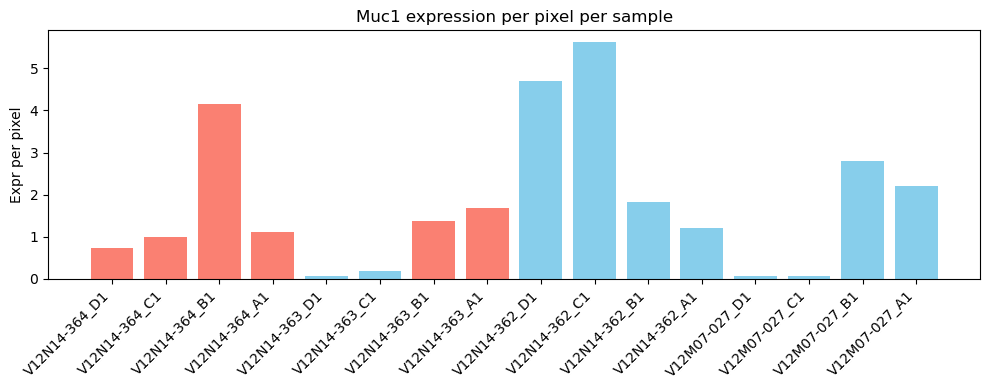

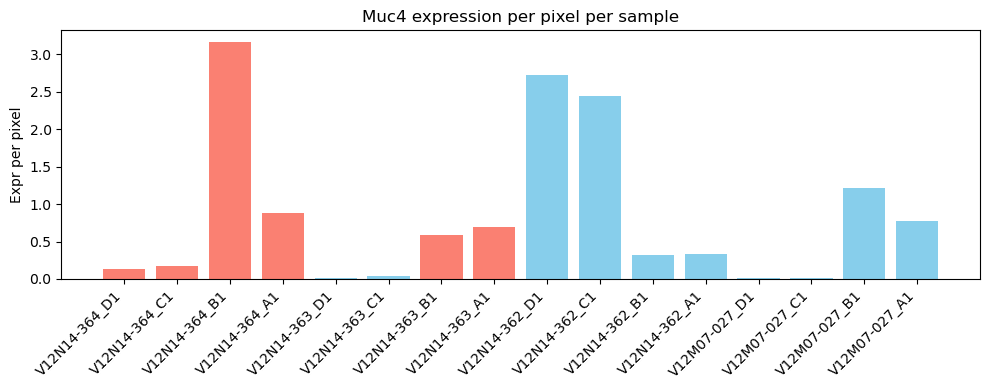

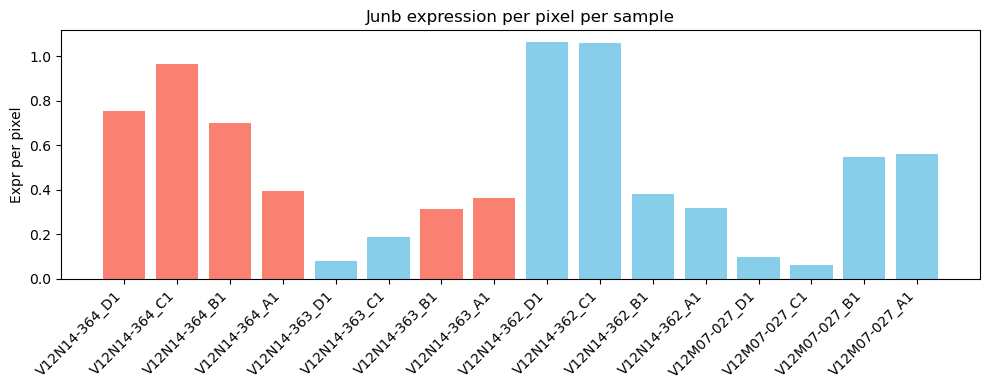

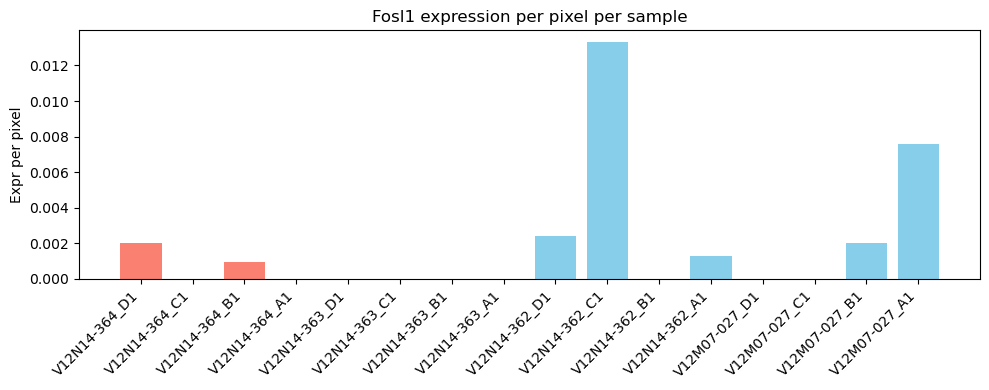

In [4]:
adata_to_sample = {}
for key, adata in adata_dict.items():
    if 'spatial' in adata.uns:
        sample_core = list(adata.uns['spatial'].keys())[0]
        adata_to_sample[key] = sample_core
    else:
        adata_to_sample[key] = key  # fallback
import matplotlib.pyplot as plt
import numpy as np

genes = ["Muc1", "Muc4", "Junb","Fosl1"]
group_colors = {"Aged": "skyblue", "Young": "salmon"}

for gene in genes:
    values = []
    sample_names = []
    colors = []

    for adata_key, adata in adata_dict.items():
        sample_name = adata_to_sample[adata_key] 
        sample_names.append(sample_name)
        group = sample_info[sample_name]
        colors.append(group_colors[group])

        if gene in adata.var_names:
            expr = adata[:, gene].X
            if hasattr(expr, "toarray"):
                expr = expr.toarray()
            expr = expr.flatten()

            if 'in_tissue' in adata.obs.columns:
                n_pixels = adata.obs['in_tissue'].sum()
            else:
                n_pixels = adata.obs.shape[0]

            expr_per_pixel = expr.sum() / n_pixels
            values.append(round(expr_per_pixel, 10))
        else:
            values.append(0.0)

    plt.figure(figsize=(10,4))
    plt.bar(sample_names, values, color=colors)
    plt.ylabel("Expr per pixel")
    plt.xticks(rotation=45, ha='right')
    plt.title(f"{gene} expression per pixel per sample")
    plt.tight_layout()
    plt.show()

In [5]:
for key, adata in adata_dict.items():
    print(f"adata_dict key: {key}")
    
    # 1) obs 확인
    print("  obs head:")
    print(adata.obs.head())
    
    # 2) uns['spatial'] 확인 (hires 이미지 경로나 scalefactors에 sample_core가 들어있을 수 있음)
    if 'spatial' in adata.uns:
        print("  uns['spatial'] keys:", list(adata.uns['spatial'].keys()))
        for lib in adata.uns['spatial']:
            images = adata.uns['spatial'][lib].get('images', {})
            print("    hires image:", images.get('hires', 'N/A'))
    
    print("-"*50)


adata_dict key: young_1
  obs head:
                    in_tissue
AAACAAGTATCTCCCA-1          1
AAACAGAGCGACTCCT-1          1
AAACAGTGTTCCTGGG-1          1
AAACCGTTCGTCCAGG-1          1
AAAGTGTGATTTATCT-1          1
  uns['spatial'] keys: ['V12N14-364_D1']
    hires image: /home/NAS/kykim/Oval/E-MTAB-12105/V12N14-364_D1_tissue_hires_image.png
--------------------------------------------------
adata_dict key: young_2
  obs head:
                    in_tissue
AAACAGTGTTCCTGGG-1          1
AAACCTAAGCAGCCGG-1          1
AAACGAGACGGTTGAT-1          1
AAACGGGCGTACGGGT-1          1
AAAGTTGACTCCCGTA-1          1
  uns['spatial'] keys: ['V12N14-364_C1']
    hires image: /home/NAS/kykim/Oval/E-MTAB-12105/V12N14-364_C1_tissue_hires_image.png
--------------------------------------------------
adata_dict key: young_3
  obs head:
                    in_tissue
AAACATTTCCCGGATT-1          1
AAACCGTTCGTCCAGG-1          1
AAACCTAAGCAGCCGG-1          1
AAACGAGACGGTTGAT-1          1
AAACGGGCGTACGGGT-1    

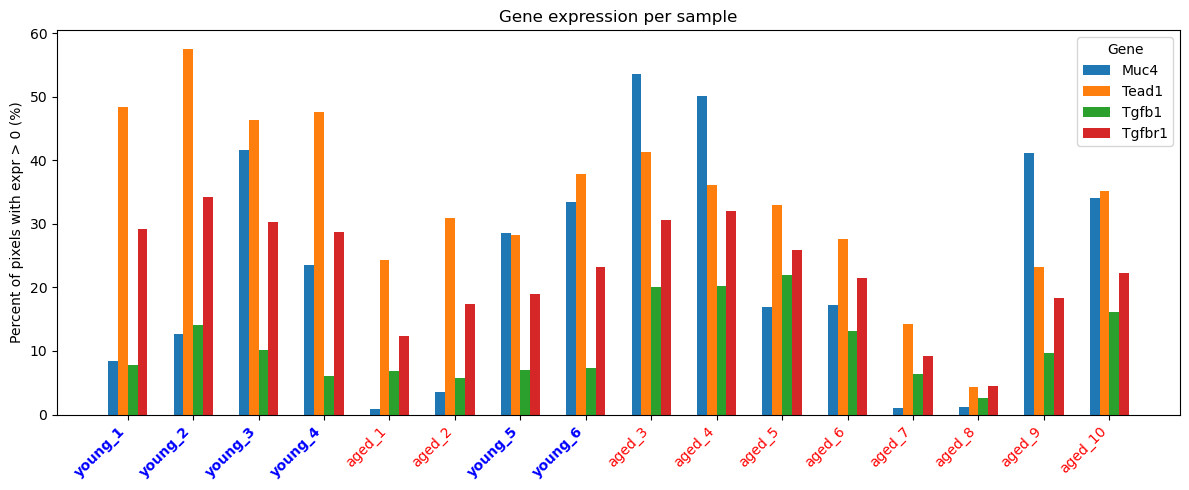

In [6]:
import matplotlib.pyplot as plt
import numpy as np

genes = ["Muc4", "Tead1","Tgfb1","Tgfbr1"]

gene_colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"]
group_colors = {
    "aged": "red", 
    "young": "blue"
}

sample_names = list(adata_dict.keys())
n_samples = len(sample_names)
n_genes = len(genes)
bar_width = 0.15

values_dict = {gene: [] for gene in genes}
groups = []

for sample_name, adata in adata_dict.items():
    group = "aged" if "aged" in sample_name else "young"
    groups.append(group)
    
    for gene in genes:
        if gene in adata.var_names:
            expr = adata[:, gene].X
            if hasattr(expr, "toarray"):
                expr = expr.toarray()
            expr = expr.flatten()
            if 'in_tissue' in adata.obs.columns:
                in_tissue_mask = adata.obs['in_tissue'].values.astype(bool)
                expr_in_tissue = expr[in_tissue_mask]
            else:
                expr_in_tissue = expr
            n_pixels = len(expr_in_tissue)
            n_expr_positive = np.sum(expr_in_tissue > 0)
            percent_expr = n_expr_positive / n_pixels * 100
            values_dict[gene].append(percent_expr)
        else:
            values_dict[gene].append(0.0)

x = np.arange(n_samples)
plt.figure(figsize=(12,5))

for i, gene in enumerate(genes):
    plt.bar(x + i*bar_width, values_dict[gene], width=bar_width, label=gene, color=gene_colors[i])

plt.xticks(x + bar_width*(n_genes-1)/2, sample_names, rotation=45, ha='right')

ax = plt.gca()
for tick_label, group in zip(ax.get_xticklabels(), groups):
    if group == "young":
        tick_label.set_color(group_colors["young"])
        tick_label.set_fontweight("bold")
    else:
        tick_label.set_color(group_colors["aged"])
        tick_label.set_fontweight("normal")

plt.ylabel("Percent of pixels with expr > 0 (%)")
plt.title("Gene expression per sample")
plt.legend(title="Gene")
plt.tight_layout()
plt.show()

# Data save

In [4]:
import scanpy as sc
import pandas as pd
import json
from PIL import Image
import numpy as np
import os

base = "/home/NAS/kykim/Oval/E-MTAB-12105"
out = "/home/Data_Drive_8TB/kykim/1. Oval/Spatial/Save_data"
os.makedirs(out, exist_ok=True)

sample_info = {
    "V12N14-364_D1": "Young1",
    "V12N14-364_C1": "Young2",
    "V12N14-364_B1": "Young3",
    "V12N14-364_A1": "Young4",
    "V12N14-363_D1": "Aged1",
    "V12N14-363_C1": "Aged2",
    "V12N14-363_B1": "Young5",
    "V12N14-363_A1": "Young6",
    "V12N14-362_D1": "Aged3",
    "V12N14-362_C1": "Aged4",
    "V12N14-362_B1": "Aged5",
    "V12N14-362_A1": "Aged6",
    "V12M07-027_D1": "Aged7",
    "V12M07-027_C1": "Aged8",
    "V12M07-027_B1": "Aged9",
    "V12M07-027_A1": "Aged10"
}

for sample, group in sample_info.items():
    h5 = f"{base}/{sample}_filtered_feature_bc_matrix.h5"
    posf = f"{base}/{sample}_tissue_positions_list.csv"
    imgf = f"{base}/{sample}_tissue_hires_image.png"
    scalef = f"{base}/{sample}_scalefactors_json.json"

    if not all(map(os.path.exists, [h5, posf, imgf, scalef])):
        continue

    adata = sc.read_10x_h5(h5)
    adata.var_names_make_unique()

    pos = pd.read_csv(posf, header=None)
    pos.columns = [
        "barcode",
        "in_tissue",
        "array_row",
        "array_col",
        "pxl_row_in_fullres",
        "pxl_col_in_fullres",
    ]
    pos = pos.set_index("barcode")

    common = adata.obs_names.intersection(pos.index)
    adata = adata[common].copy()
    pos = pos.loc[common]

    adata.obs["in_tissue"] = pos["in_tissue"].astype(int)
    adata.obsm["spatial"] = pos[
        ["pxl_col_in_fullres", "pxl_row_in_fullres"]
    ].values

    with open(scalef) as f:
        scalefactors = json.load(f)

    img = np.array(Image.open(imgf))

    adata.uns["spatial"] = {
        sample: {
            "images": {"hires": img},
            "scalefactors": scalefactors,
            "metadata": {},
        }
    }

    adata.obs["sample_id"] = sample
    adata.obs["group"] = group

    fname = sample.replace("-", "_") + f"_{group}.h5ad"
    adata.write(f"{out}/{fname}")

/home/Data_Drive_8TB/kykim/.conda/envs/kykim/lib/python3.9/site-packages/anndata/_core/anndata.py:1820: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/home/Data_Drive_8TB/kykim/.conda/envs/kykim/lib/python3.9/site-packages/anndata/_core/anndata.py:1820: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/home/Data_Drive_8TB/kykim/.conda/envs/kykim/lib/python3.9/site-packages/anndata/_core/anndata.py:1820: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/home/Data_Drive_8TB/kykim/.conda/envs/kykim/lib/python3.9/site-packages/anndata/_core/anndata.py:1820: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/home/Data_Drive_8TB/kykim/.conda/envs/kykim/lib/pyt

In [1]:
################ Merge 객체 ####################

In [2]:
import scanpy as sc
import os

indir = "/home/Data_Drive_8TB/kykim/1. Oval/Spatial/Save_data"
outdir = "/home/Data_Drive_8TB/kykim/1. Oval/Spatial/Save_data/merge_visium"
os.makedirs(outdir, exist_ok=True)

files = [f for f in os.listdir(indir) if f.endswith(".h5ad")]

adatas = []
for f in files:
    adata = sc.read(os.path.join(indir, f))
    adatas.append(adata)

adata_merged = sc.concat(adatas, join="outer", label="sample_id", keys=[a.obs["sample_id"][0] for a in adatas])
adata_merged.write(os.path.join(outdir, "merged_visium.h5ad"))

/tmp/ipykernel_2376000/879745658.py:15: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  adata_merged = sc.concat(adatas, join="outer", label="sample_id", keys=[a.obs["sample_id"][0] for a in adatas])
/home/Data_Drive_8TB/kykim/.conda/envs/kykim/lib/python3.9/site-packages/anndata/_core/anndata.py:1818: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [3]:
adata_merged

AnnData object with n_obs × n_vars = 16934 × 32285
    obs: 'in_tissue', 'sample_id', 'group'
    obsm: 'spatial'